# Task 4 — Distributions, box plots & outlier treatment

**Problem-statement step:** *Generate box plots and histograms to gain insights into the distributions and identify outliers. Implement outlier treatment as needed.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

# Locate the raw data whether the notebook is opened from its own folder
# (notebooks/) or from the project root.
import os
_CANDIDATES = ["marketing_data.csv", "../marketing_data.csv",
               os.path.join(os.path.dirname(os.getcwd()), "marketing_data.csv")]
DATA_PATH = next((p for p in _CANDIDATES if os.path.exists(p)), "marketing_data.csv")
print("Using data file:", DATA_PATH)

Using data file: ../marketing_data.csv


In [2]:
REFERENCE_YEAR = 2015  # data compiled just after the last enrolment (Jun 2014)
SPEND_COLS = ["MntWines", "MntFruits", "MntMeatProducts",
              "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
CHANNEL_COLS = ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]

def load_and_prepare(path=DATA_PATH, engineer=True):
    """Load -> fix dtypes -> clean categories -> impute income -> features."""
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()                     # ' Income ' -> 'Income'
    if not pd.api.types.is_numeric_dtype(df["Income"]):     # '$84,835.00' -> float
        df["Income"] = (df["Income"].astype("string")
                        .str.replace(r"[\$,]", "", regex=True).str.strip().astype(float))
    df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%m/%d/%y")
    df["Marital_Status"] = df["Marital_Status"].replace(
        {"Alone": "Single", "YOLO": "Single", "Absurd": "Single"})
    df["Income"] = df.groupby(["Education", "Marital_Status"])["Income"].transform(
        lambda s: s.fillna(s.median()))
    df["Income"] = df["Income"].fillna(df["Income"].median())
    if engineer:
        df["Kids"] = df["Kidhome"] + df["Teenhome"]
        df["Age"] = REFERENCE_YEAR - df["Year_Birth"]
        df["Total_Spending"] = df[SPEND_COLS].sum(axis=1)
        df["Total_Purchases"] = df[CHANNEL_COLS].sum(axis=1)
        df["Total_Accepted_Cmp"] = df[["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
                                       "AcceptedCmp4", "AcceptedCmp5"]].sum(axis=1)
        df["Has_Child"] = (df["Kids"] > 0).astype(int)
        df["Is_US"] = (df["Country"] == "US").astype(int)
    return df

def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    return q1 - k * (q3 - q1), q3 + k * (q3 - q1)

def treat_outliers(df):
    """Drop impossible ages and winsorise heavy-tailed continuous columns."""
    df = df[df["Age"] <= 100].copy()
    for col in ["Income", "Total_Spending", "Total_Purchases", "NumWebVisitsMonth"]:
        lo, hi = iqr_bounds(df[col])
        df[col] = df[col].clip(lo, hi)
    return df

In [3]:
df = load_and_prepare()
NUMERIC_VARS = ["Age", "Income", "Total_Spending", "Total_Purchases",
                "Recency", "NumWebVisitsMonth"]

## 1. Histograms — distribution shape

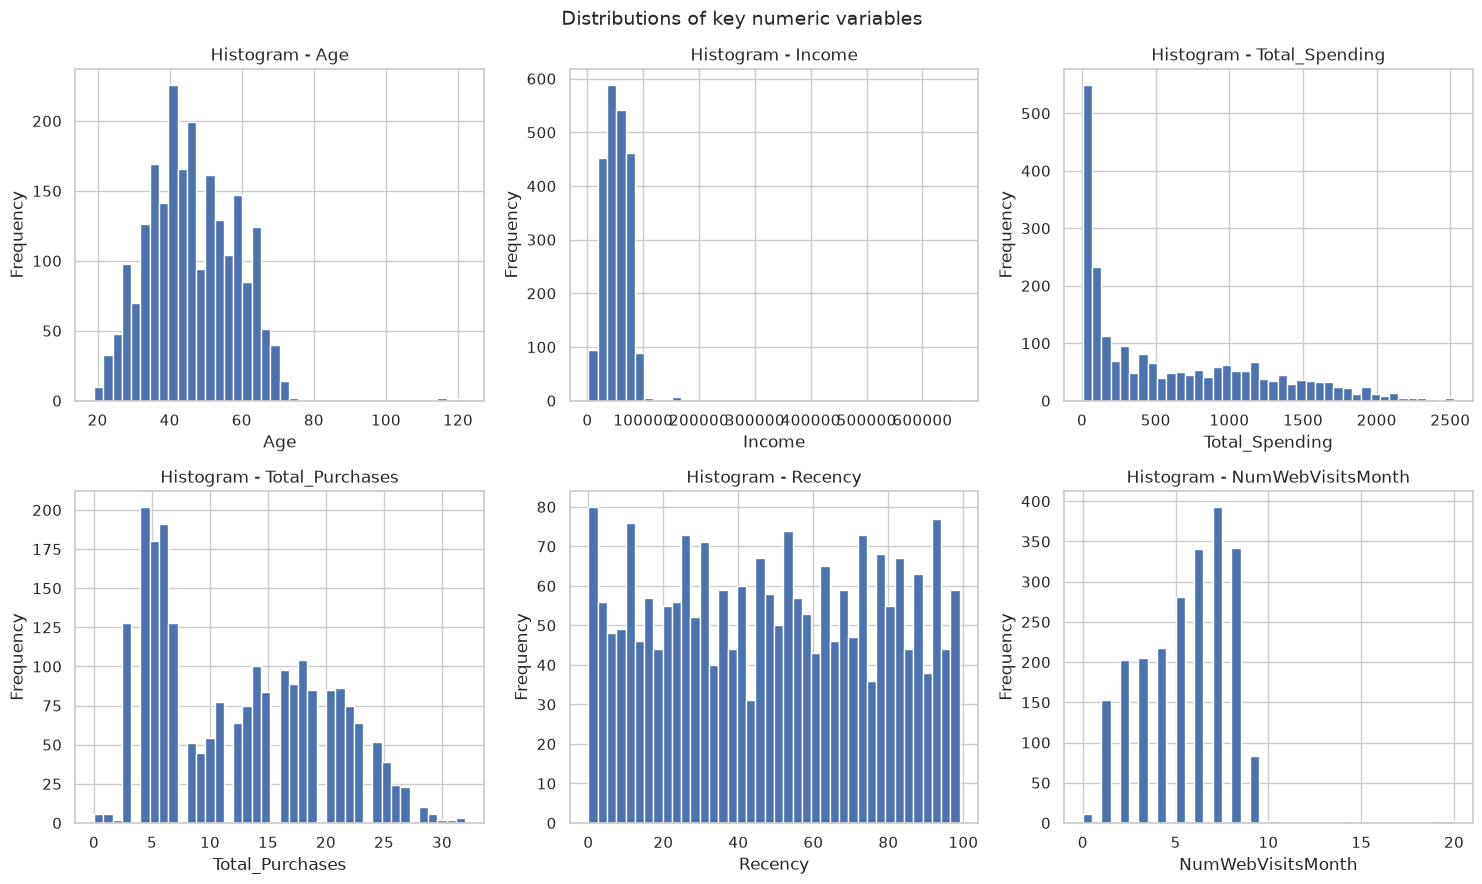

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, col in zip(axes.ravel(), NUMERIC_VARS):
    ax.hist(df[col], bins=40, color="#4C72B0", edgecolor="white")
    ax.set_title(f"Histogram - {col}"); ax.set_xlabel(col); ax.set_ylabel("Frequency")
fig.suptitle("Distributions of key numeric variables", fontsize=14)
fig.tight_layout(); plt.show()

## 2. Box plots — *before* treatment

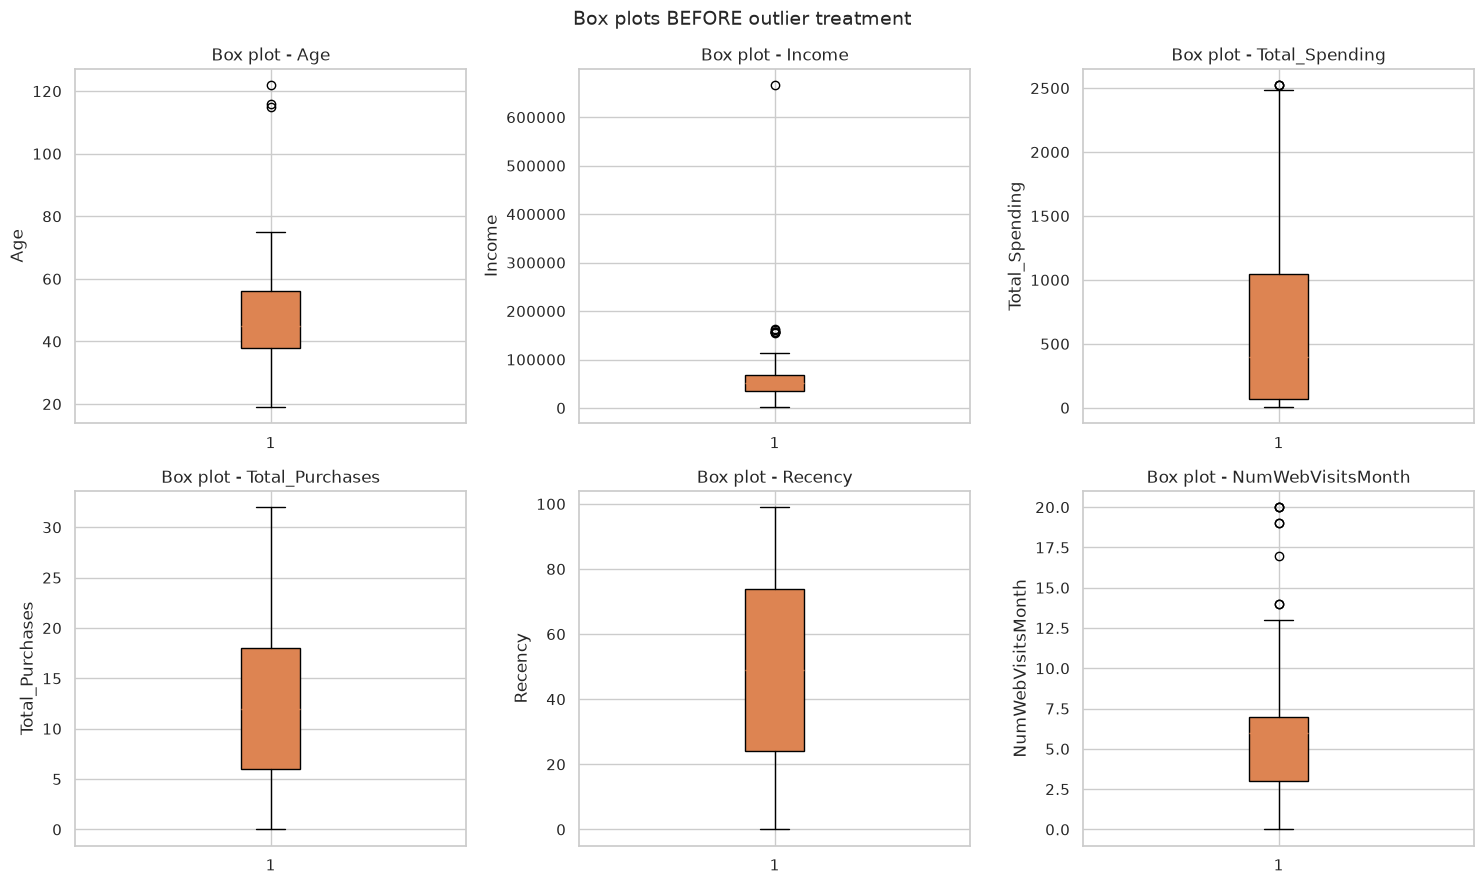

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, col in zip(axes.ravel(), NUMERIC_VARS):
    ax.boxplot(df[col], patch_artist=True, boxprops=dict(facecolor="#DD8452"))
    ax.set_title(f"Box plot - {col}"); ax.set_ylabel(col)
fig.suptitle("Box plots BEFORE outlier treatment", fontsize=14)
fig.tight_layout(); plt.show()

## 3. Detect outliers with the IQR (1.5×) rule

In [6]:
for col in NUMERIC_VARS:
    lo, hi = iqr_bounds(df[col])
    n = int(((df[col] < lo) | (df[col] > hi)).sum())
    print(f"{col:18s}: {n:4d} outliers  (fences {lo:.0f} .. {hi:.0f})")

Age               :    3 outliers  (fences 11 .. 83)
Income            :    8 outliers  (fences -13588 .. 117416)
Total_Spending    :    3 outliers  (fences -1396 .. 2511)
Total_Purchases   :    0 outliers  (fences -12 .. 36)
Recency           :    0 outliers  (fences -51 .. 149)
NumWebVisitsMonth :    8 outliers  (fences -3 .. 13)


## 4. Treat the outliers
* remove physically impossible ages (`Age > 100`),
* winsorise (cap) the heavy-tailed continuous variables at their IQR fences.

In [7]:
before = len(df)
df = df[df["Age"] <= 100].copy()
print("Removed", before - len(df), "impossible-age rows")
for col in ["Income", "Total_Spending", "Total_Purchases", "NumWebVisitsMonth"]:
    lo, hi = iqr_bounds(df[col]); df[col] = df[col].clip(lo, hi)
print("Winsorised: Income, Total_Spending, Total_Purchases, NumWebVisitsMonth")

Removed 3 impossible-age rows
Winsorised: Income, Total_Spending, Total_Purchases, NumWebVisitsMonth


## 5. Box plots — *after* treatment

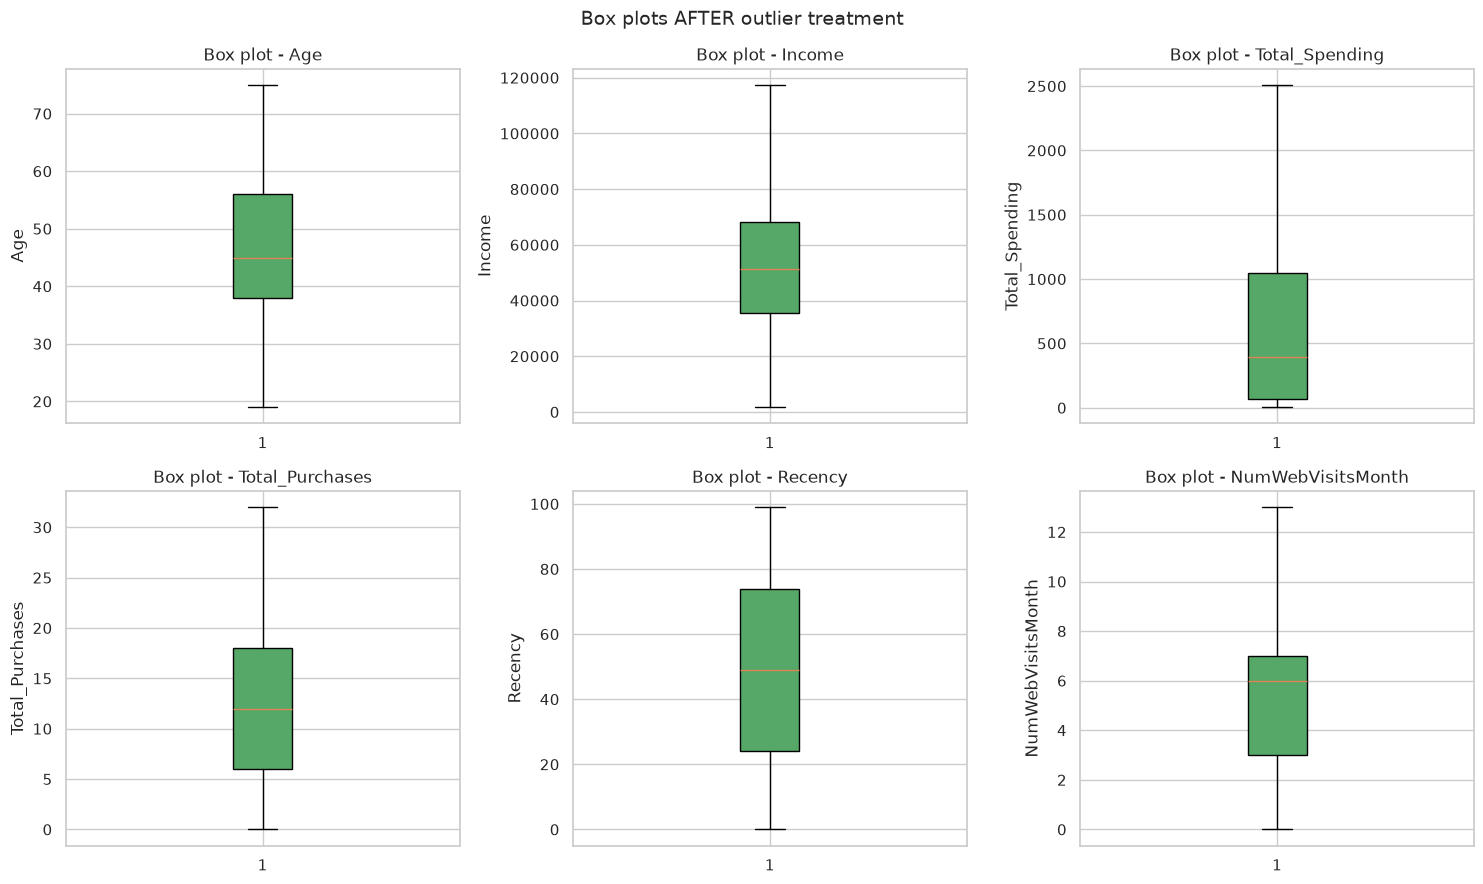

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, col in zip(axes.ravel(), NUMERIC_VARS):
    ax.boxplot(df[col], patch_artist=True, boxprops=dict(facecolor="#55A868"))
    ax.set_title(f"Box plot - {col}"); ax.set_ylabel(col)
fig.suptitle("Box plots AFTER outlier treatment", fontsize=14)
fig.tight_layout(); plt.show()

### Conclusion
`Income`, `Total_Spending` and `Age` were the most outlier-prone. 3 impossible-age rows removed and continuous variables winsorised, so extremes no longer distort the later analysis.